## Fine-tune ResNet-18 trên CIFAR-10

Notebook này:
- Load ResNet-18 pretrained ImageNet
- Thay lớp FC cuối thành 10 lớp (CIFAR-10)
- Huấn luyện trên train set, kiểm tra trên test set
- Lưu mô hình tốt nhất vào `model/resnet18_finetuned_cifar10.pt`

**Sau khi fine-tune:** Dùng mô hình đã lưu làm backbone trích đặc trưng (bỏ lớp FC) trong `Feature_extraction.ipynb` hoặc `feature_extractor.py` để cải thiện chất lượng retrieval.

Chạy **sau** notebook 01 (Data_process) để có dữ liệu trong `Data/`.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [2]:
# Đường dẫn: Data/ và thư mục lưu mô hình
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "src" else cwd
DATA_ROOT = str(PROJECT_ROOT / "Data")
MODEL_DIR = PROJECT_ROOT / "model"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = MODEL_DIR / "resnet18_finetuned_cifar10.pt"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("Save model to:", CHECKPOINT_PATH)

PROJECT_ROOT: /home/hoang/Image-Retrieval-System
DATA_ROOT: /home/hoang/Image-Retrieval-System/Data
Save model to: /home/hoang/Image-Retrieval-System/model/resnet18_finetuned_cifar10.pt


In [3]:
# Tiền xử lý giống pipeline hiện tại (ImageNet)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

trainset = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=True, download=False, transform=transform)
testset  = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=False, download=False, transform=transform)

train_loader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=0, pin_memory=False)
test_loader  = torch.utils.data.DataLoader(testset,  batch_size=128, shuffle=False, num_workers=0)

print("Train batches:", len(train_loader), "| Test batches:", len(test_loader))

Train batches: 782 | Test batches: 79


In [4]:
# Load ResNet-18 pretrained, thay FC cuối thành 10 lớp (CIFAR-10)
num_classes = 10

try:
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
except Exception:
    model = models.resnet18(pretrained=True)

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)
model = model.to(device)

# Tùy chọn: chỉ train lớp fc (nhanh), hoặc fine-tune toàn bộ (chất lượng tốt hơn)
FREEZE_BACKBONE = False  # True = chỉ train fc; False = fine-tune cả mạng

if FREEZE_BACKBONE:
    for name, param in model.named_parameters():
        if "fc" not in name:
            param.requires_grad = False
    print("Đã đóng băng backbone, chỉ train lớp fc.")
else:
    print("Fine-tune toàn bộ mạng (lr nhỏ cho backbone).")

Fine-tune toàn bộ mạng (lr nhỏ cho backbone).


In [5]:
# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

num_epochs = 5  # Có thể tăng 10–15 nếu muốn hội tụ hơn

In [6]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader), correct / total

def eval_model(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return correct / total

In [7]:
best_acc = 0.0
for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    scheduler.step()
    test_acc = eval_model(model, test_loader, device)
    print(f"Epoch {epoch}/{num_epochs} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Test acc: {test_acc:.4f}")
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  -> Đã lưu checkpoint (test acc {test_acc:.4f})")

print(f"\nKết thúc. Test accuracy tốt nhất: {best_acc:.4f}")
print(f"Mô hình đã lưu: {CHECKPOINT_PATH}")

Epoch 1/5 | Train loss: 0.5505 | Train acc: 0.8117 | Test acc: 0.8192
  -> Đã lưu checkpoint (test acc 0.8192)
Epoch 2/5 | Train loss: 0.3170 | Train acc: 0.8915 | Test acc: 0.8415
  -> Đã lưu checkpoint (test acc 0.8415)
Epoch 3/5 | Train loss: 0.2250 | Train acc: 0.9219 | Test acc: 0.8970
  -> Đã lưu checkpoint (test acc 0.8970)
Epoch 4/5 | Train loss: 0.0735 | Train acc: 0.9754 | Test acc: 0.9276
  -> Đã lưu checkpoint (test acc 0.9276)
Epoch 5/5 | Train loss: 0.0417 | Train acc: 0.9859 | Test acc: 0.9172

Kết thúc. Test accuracy tốt nhất: 0.9276
Mô hình đã lưu: /home/hoang/Image-Retrieval-System/model/resnet18_finetuned_cifar10.pt


### Chỉ số đánh giá fine-tune (bài toán phân lớp CIFAR-10)

Fine-tune là bài toán **classification** (10 lớp), nên dùng các chỉ số sau:

| Chỉ số | Ý nghĩa |
|--------|--------|
| **Accuracy** | Tỉ lệ ảnh dự đoán đúng lớp trên toàn bộ test set. |
| **Precision (từng lớp)** | Trong số ảnh model dự đoán là lớp X, bao nhiêu % thực sự là lớp X. |
| **Recall (từng lớp)** | Trong số ảnh thực sự thuộc lớp X, bao nhiêu % được model dự đoán đúng. |
| **F1 (từng lớp)** | Trung bình điều hòa của Precision và Recall cho lớp đó. |
| **Macro F1** | Trung bình F1 của 10 lớp (mỗi lớp tính bằng nhau). |
| **Weighted F1** | Trung bình F1 có trọng số theo số lượng mẫu mỗi lớp. |
| **Confusion matrix** | Ma trận: hàng = nhãn thật, cột = dự đoán; ô (i,j) = số ảnh lớp i bị dự đoán là lớp j. |

Sau khi train xong, chạy cell bên dưới để in các chỉ số này trên **test set**.

In [10]:
# Load lại mô hình tốt nhất (checkpoint đã lưu) và đánh giá chi tiết trên test set
import numpy as np
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        out = model(inputs)
        _, pred = out.max(1)
        all_preds.append(pred.cpu().numpy())
        all_labels.append(labels.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)

# Chỉ số phân lớp (sklearn)
from sklearn.metrics import classification_report, confusion_matrix

class_names = testset.classes  # ['airplane', 'automobile', 'bird', 'cat', ...]

print("=" * 60)
print("BÁO CÁO PHÂN LỚP (Test set)")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

print("\nConfusion matrix (hàng = thật, cột = dự đoán):")
print(confusion_matrix(y_true, y_pred))

# Macro F1 & Weighted F1 (tổng hợp)
from sklearn.metrics import f1_score
macro_f1 = f1_score(y_true, y_pred, average="macro")
weighted_f1 = f1_score(y_true, y_pred, average="weighted")
print(f"\nMacro F1:    {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")
print("=" * 60)

/tmp/ipykernel_19790/2034872622.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))


BÁO CÁO PHÂN LỚP (Test set)
              precision    recall  f1-score   support

    airplane     0.9309    0.9300    0.9305      1000
  automobile     0.9575    0.9690    0.9632      1000
        bird     0.9235    0.8930    0.9080      1000
         cat     0.8225    0.8710    0.8460      1000
        deer     0.9451    0.9290    0.9370      1000
         dog     0.8882    0.8820    0.8851      1000
        frog     0.9407    0.9510    0.9458      1000
       horse     0.9701    0.9410    0.9553      1000
        ship     0.9634    0.9480    0.9556      1000
       truck     0.9413    0.9620    0.9515      1000

    accuracy                         0.9276     10000
   macro avg     0.9283    0.9276    0.9278     10000
weighted avg     0.9283    0.9276    0.9278     10000


Confusion matrix (hàng = thật, cột = dự đoán):
[[930   4  13   9   4   0   4   1  17  18]
 [  4 969   0   0   0   0   0   0   5  22]
 [ 19   2 893  31  15  17  16   3   3   1]
 [  9   4  11 871   8  70  17   3   

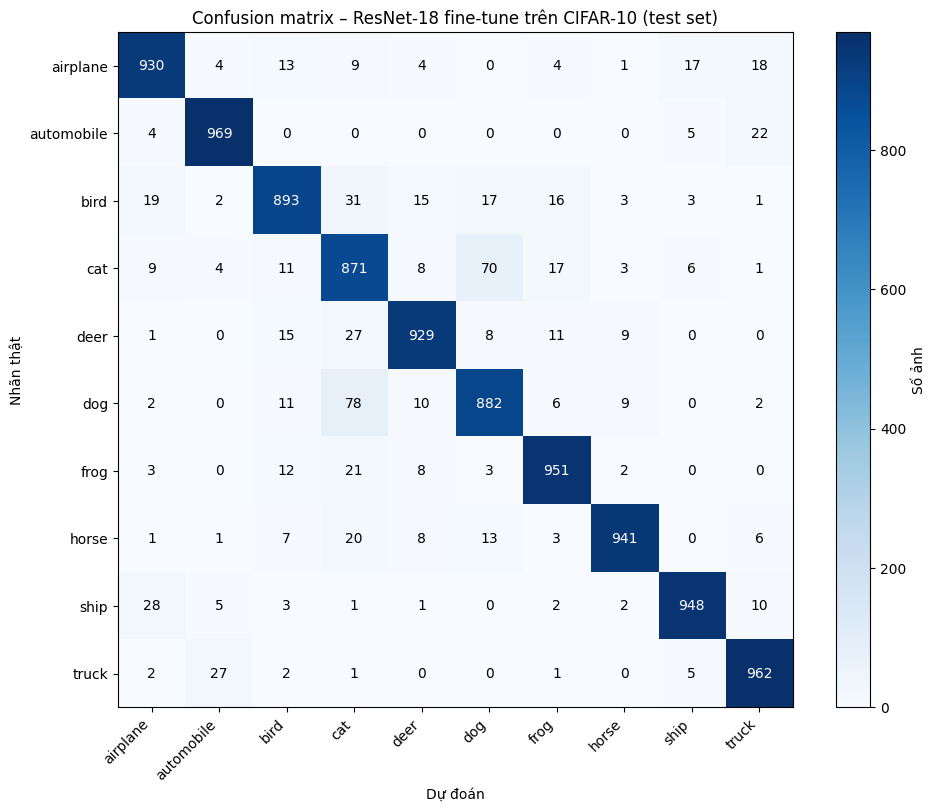

In [11]:
# (Tuỳ chọn) Vẽ confusion matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Dự đoán")
ax.set_ylabel("Nhãn thật")
plt.colorbar(im, ax=ax, label="Số ảnh")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black" if cm[i, j] < cm.max()/2 else "white")
plt.tight_layout()
plt.title("Confusion matrix – ResNet-18 fine-tune trên CIFAR-10 (test set)")
plt.show()

### Dùng mô hình đã fine-tune để trích đặc trưng

Sau khi chạy xong, load checkpoint và **bỏ lớp FC** để lấy vector 512 chiều (giống ResNet gốc). Ví dụ:

```python
model = models.resnet18(weights=None)  # không load ImageNet
model.fc = nn.Linear(model.fc.in_features, 10)  # tạm có 10 lớp
model.load_state_dict(torch.load('model/resnet18_finetuned_cifar10.pt', map_location='cpu'))
backbone = nn.Sequential(*list(model.children())[:-1])  # bỏ fc → trích 512-D
backbone.eval()
```

Rồi dùng `backbone` thay cho `model` trong **Feature_extraction.ipynb** (cell load ResNet) hoặc trong **feature_extractor.py** khi trích đặc trưng. Nhớ chạy lại trích đặc trưng để tạo lại `features.npy` và `image_list.txt`.